In [13]:
import io, json, time
import numpy as np, pandas as pd, requests

FRED_KEY = "enter-fred-api-key-here"   # fredaccount.stlouisfed.org/apikeys

START, END = "2021-08-01", "2026-08-04"    # IORB begins 2021-07-29
UA = {"User-Agent": "intraday-liquidity-research/1.0 (student research)"}

FRED_SERIES = {
    # Balance sheet / quantity of reserves — the scarce resource
    "WRESBAL":"Reserve balances ($B, weekly)",
    "WALCL":"Fed total assets ($M, weekly)",
    "WTREGEN":"Treasury General Account ($B, weekly)",
    "WLCFLPCL":"Discount window primary credit ($M, weekly)",
    # Open market operations
    "RPONTSYD":"Overnight repo, Treasury securities purchased ($B)",
    "RRPONTSYD":"Overnight reverse repo, Treasury securities sold ($B)",
    # Policy corridor
    "IORB":"Interest on reserve balances (%)",
    "DFEDTARU":"Target range upper (%)",
    "DFEDTARL":"Target range lower (%)",
    # Secured overnight rates — percentiles are the intraday tightness proxy
    "SOFR":"SOFR volume-weighted median (%)",
    "SOFR1":"SOFR 1st percentile (%)",
    "SOFR25":"SOFR 25th percentile (%)",
    "SOFR75":"SOFR 75th percentile (%)",
    "SOFR99":"SOFR 99th percentile (%)",
    "SOFRVOL":"SOFR transaction volume ($B)",
    "BGCR":"Broad general collateral rate (%)",
    "TGCR":"Tri-party general collateral rate (%)",
    # Unsecured
    "EFFR":"Effective fed funds rate (%)",
    "EFFR1":"EFFR 1st percentile (%)",
    "EFFR99":"EFFR 99th percentile (%)",
    "EFFRVOL":"Fed funds transaction volume ($B)",
    "OBFR":"Overnight bank funding rate (%)",
}
CRITICAL = {"IORB", "SOFR", "SOFR99", "WRESBAL"}

assert len(FRED_KEY) == 32, "FRED key must be 32 characters"
print(f"{len(FRED_SERIES)} series | {START} → {END}")

22 series | 2021-08-01 → 2026-08-04


In [14]:
sess = requests.Session()
sess.headers.update(UA)
sess.mount("https://", requests.adapters.HTTPAdapter(pool_connections=8, pool_maxsize=8))
_cache = {}

def fetch(url, params=None, retries=3, timeout=30):
    key = url + json.dumps(params or {}, sort_keys=True)
    if key in _cache:
        return _cache[key]
    for attempt in range(1, retries + 1):
        try:
            r = sess.get(url, params=params, timeout=timeout)
            if r.status_code == 429 or r.status_code >= 500:
                raise requests.HTTPError(f"HTTP {r.status_code}")
            r.raise_for_status()
            if not r.content:
                raise ValueError("empty body")
            _cache[key] = r.content
            time.sleep(0.3)
            return r.content
        except (requests.ConnectTimeout, requests.ReadTimeout) as e:
            raise RuntimeError(f"{url}: host unreachable, not retrying") from e
        except Exception:
            if attempt == retries:
                raise
            time.sleep(2 ** attempt)

In [15]:
def fred_series(sid):
    raw = fetch("https://api.stlouisfed.org/fred/series/observations",
                {"series_id": sid, "api_key": FRED_KEY, "file_type": "json",
                 "observation_start": START, "observation_end": END})
    obs = json.loads(raw).get("observations", [])
    if not obs:
        raise ValueError("no observations")
    df = pd.DataFrame(obs)[["date", "value"]].rename(columns={"value": sid})
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df[sid] = pd.to_numeric(df[sid].replace(".", pd.NA), errors="coerce")  # FRED missing marker
    return df.dropna(subset=["date"]).reset_index(drop=True)

fred = {}
for sid in FRED_SERIES:
    try:
        fred[sid] = fred_series(sid)
        print(f"  {sid:<12} {len(fred[sid]):>5} rows  {fred[sid][sid].notna().sum():>5} non-null")
    except Exception as e:
        print(f"  {sid:<12} FAILED: {type(e).__name__}: {e}")

absent = CRITICAL - set(fred)
print(f"\n{len(fred)}/{len(FRED_SERIES)} retrieved | "
      + ("CRITICAL OK" if not absent else f"MISSING {absent} — STOP"))

if "RPONTSYD" in fred:
    rp = fred["RPONTSYD"]
    print(f"\nRPONTSYD: {(rp['RPONTSYD'] > 0).sum()} non-zero of {len(rp)} days. Largest:")
    print(rp.nlargest(6, "RPONTSYD")[["date","RPONTSYD"]].to_string(index=False))

  WRESBAL        261 rows    261 non-null
  WALCL          261 rows    261 non-null
  WTREGEN        261 rows    261 non-null
  WLCFLPCL       261 rows    261 non-null
  RPONTSYD      1307 rows   1249 non-null
  RRPONTSYD     1307 rows   1249 non-null
  IORB          1830 rows   1830 non-null
  DFEDTARU      1830 rows   1830 non-null
  DFEDTARL      1830 rows   1830 non-null
  SOFR          1307 rows   1249 non-null
  SOFR1         1307 rows   1248 non-null
  SOFR25        1307 rows   1248 non-null
  SOFR75        1307 rows   1248 non-null
  SOFR99        1307 rows   1248 non-null
  SOFRVOL       1307 rows   1249 non-null
  BGCR         FAILED: HTTPError: 400 Client Error: Bad Request for url: https://api.stlouisfed.org/fred/series/observations?series_id=BGCR&api_key=1b9054580b0e52b2cf65d5cdce1abcd2&file_type=json&observation_start=2021-08-01&observation_end=2026-08-04
  TGCR         FAILED: HTTPError: 400 Client Error: Bad Request for url: https://api.stlouisfed.org/fred/series/observ

In [16]:
fdic_parts = []
for repdte in [d.strftime("%Y%m%d") for d in pd.date_range(START, END, freq="QE")][-8:]:
    pages, offset = [], 0
    while True:
        try:
            p = json.loads(fetch("https://banks.data.fdic.gov/api/financials", {
                "filters": f"REPDTE:{repdte}",
                "fields": "CERT,REPDTE,NAME,ASSET,DEP,CHBAL,CHBALI",
                "limit": 5000, "offset": offset, "format": "json"}))
            rows = [r.get("data", r) for r in p.get("data", [])]
            if not rows: break
            pages.append(pd.json_normalize(rows))
            if len(rows) < 5000: break
            offset += 5000
        except Exception as e:
            print(f"  {repdte}: {e}"); break
    if pages:
        df = pd.concat(pages, ignore_index=True); df["REPDTE"] = repdte
        fdic_parts.append(df)
        print(f"  {repdte}  {len(df):>5} institutions")

fdic = pd.concat(fdic_parts, ignore_index=True) if fdic_parts else None

  20240930   4589 institutions
  20241231   4560 institutions
  20250331   4536 institutions
  20250630   4494 institutions
  20250930   4452 institutions
  20251231   4411 institutions
  20260331   4352 institutions


In [17]:
master = None
for sid, df in fred.items():
    master = df.copy() if master is None else master.merge(df, on="date", how="outer")
master["date"] = pd.to_datetime(master["date"]).dt.normalize()
master = master.sort_values("date").reset_index(drop=True)

for w in ("WRESBAL","WALCL","WTREGEN","WLCFLPCL"):           # weekly → daily
    if w in master: master[w] = master[w].ffill()

for a, b, n in [("SOFR99","IORB","sofr99_iorb_bps"),
                ("SOFR","IORB","sofr_iorb_bps"),
                ("SOFR99","SOFR","sofr_tail_dispersion_bps"),
                ("SOFR99","SOFR1","sofr_iqr_full_bps"),
                ("EFFR","IORB","effr_iorb_bps")]:
    if a in master and b in master:
        master[n] = (master[a] - master[b]) * 100

if fdic is not None:
    f = fdic.copy()
    f["date"]  = pd.to_datetime(f["REPDTE"], format="%Y%m%d", errors="coerce")
    f["ASSET"] = pd.to_numeric(f["ASSET"], errors="coerce")
    f["CHBAL"] = pd.to_numeric(f.get("CHBAL"), errors="coerce")
    rows = []
    for dt, g in f.dropna(subset=["date"]).groupby("date"):
        a = g["ASSET"].dropna()
        r = (g["CHBAL"] / g["ASSET"]).dropna(); r = r[(r > 0) & (r < 1)]
        rows.append({"date": dt,
                     "fdic_n_institutions": len(a),
                     "fdic_top10_asset_share": float(a.nlargest(10).sum()/a.sum()) if a.sum() else np.nan,
                     "fdic_median_cash_ratio": float(r.median()) if len(r) else np.nan})
    master = master.merge(pd.DataFrame(rows), on="date", how="outer")
    for c in [c for c in master if c.startswith("fdic_")]:
        master[c] = master[c].ffill()

master["is_month_end"]   = master["date"].dt.is_month_end
master["is_quarter_end"] = master["date"].dt.is_quarter_end
master["is_year_end"]    = (master["date"].dt.month == 12) & (master["date"].dt.day == 31)
master["weekday"]        = master["date"].dt.dayofweek
master = master.sort_values("date").drop_duplicates("date").reset_index(drop=True)

front = [c for c in ["date","WRESBAL","IORB","SOFR","SOFR99","sofr99_iorb_bps",
                     "RPONTSYD","RRPONTSYD"] if c in master.columns]
master = master[front + [c for c in master.columns if c not in front]]

assert master["date"].is_unique, "duplicate dates"
assert not any(c.endswith(("_x","_y")) for c in master.columns), "merge collision"
print(f"master: {master.shape[0]} rows × {master.shape[1]} cols "
      f"| {master['date'].min().date()} → {master['date'].max().date()}")
master.head()

master: 1830 rows × 33 cols | 2021-08-01 → 2026-08-04


,date,WRESBAL,IORB,SOFR,SOFR99,sofr99_iorb_bps,RPONTSYD,RRPONTSYD,WALCL,WTREGEN,...,sofr_tail_dispersion_bps,sofr_iqr_full_bps,effr_iorb_bps,fdic_n_institutions,fdic_top10_asset_share,fdic_median_cash_ratio,is_month_end,is_quarter_end,is_year_end,weekday
0,2021-08-01,NaN,0.15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,6
1,2021-08-02,NaN,0.15,0.05,0.15,0.0,0.0,921.317,NaN,NaN,...,10.0,14.0,-5.0,NaN,NaN,NaN,False,False,False,0
2,2021-08-03,NaN,0.15,0.05,0.15,0.0,0.0,909.442,NaN,NaN,...,10.0,13.0,-5.0,NaN,NaN,NaN,False,False,False,1
3,2021-08-04,4005578.0,0.15,0.05,0.15,0.0,0.0,931.755,8235073.0,492668.0,...,10.0,13.0,-5.0,NaN,NaN,NaN,False,False,False,2
4,2021-08-05,4005578.0,0.15,0.05,NaN,NaN,0.0,944.335,8235073.0,492668.0,...,NaN,NaN,-5.0,NaN,NaN,NaN,False,False,False,3


      date  sofr99_iorb_bps  tightness_z   WRESBAL  RPONTSYD  is_quarter_end
2024-09-30             55.0     8.773485 3169149.0     2.350            True
2025-10-31             45.0     4.993672 2848021.0    29.400           False
2024-09-19             44.0     8.334682 3313281.0     0.000           False
2024-12-26             40.0     5.150935 3247382.0     0.002           False
2024-10-01             38.0     5.500688 3169149.0     0.000           False
2025-10-30             37.0     4.214577 2848021.0     5.000           False
2025-12-31             35.0     3.137159 2957410.0    31.500            True
2024-12-31             35.0     4.113860 3247382.0     0.000            True
2025-11-03             33.0     3.378603 2848021.0     7.750           False
2025-11-28             33.0     3.105399 2896586.0    11.250           False
2024-12-27             33.0     3.995360 3247382.0     0.000           False
2025-12-01             31.0     2.811960 2896586.0    13.500           False

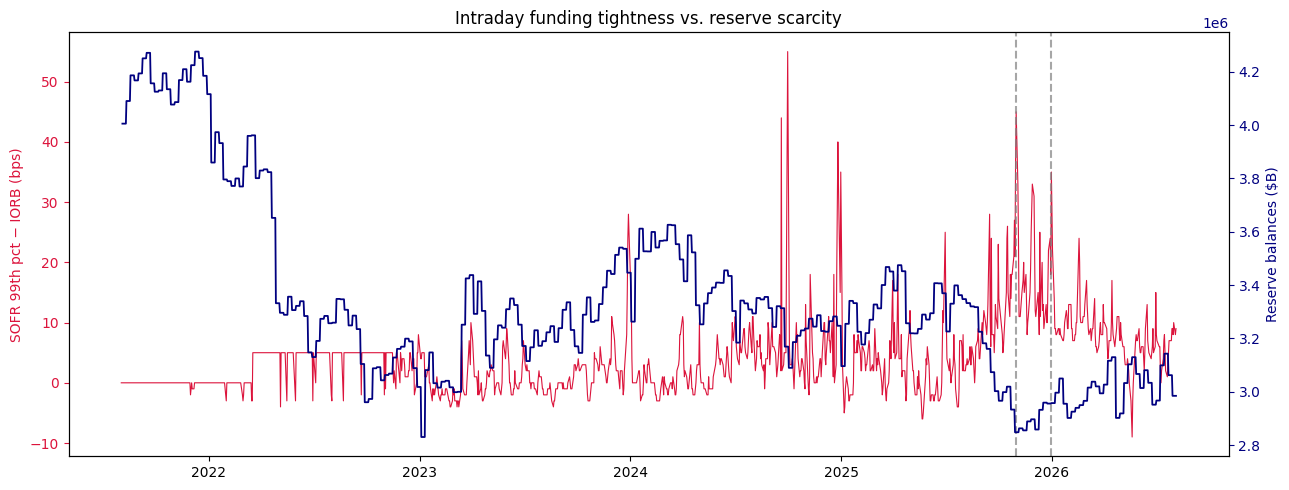

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
import matplotlib.pyplot as plt

d = master.dropna(subset=["sofr99_iorb_bps"]).copy()
roll = d["sofr99_iorb_bps"].rolling(252, min_periods=60)
d["tightness_z"] = (d["sofr99_iorb_bps"] - roll.mean()) / roll.std()
keep = [c for c in ["date","sofr99_iorb_bps","tightness_z","WRESBAL",
                    "RPONTSYD","is_quarter_end"] if c in d.columns]
stress = d.nlargest(25, "sofr99_iorb_bps")[keep]
print(stress.head(12).to_string(index=False))

fig, ax1 = plt.subplots(figsize=(13,5))
ax1.plot(d["date"], d["sofr99_iorb_bps"], lw=.8, color="crimson")
ax1.set_ylabel("SOFR 99th pct − IORB (bps)", color="crimson")
ax1.tick_params(axis="y", colors="crimson")
ax2 = ax1.twinx()
ax2.plot(master["date"], master["WRESBAL"], lw=1.3, color="navy")
ax2.set_ylabel("Reserve balances ($B)", color="navy")
ax2.tick_params(axis="y", colors="navy")
for dt in ("2025-10-31", "2025-12-31"):
    ax1.axvline(pd.Timestamp(dt), ls="--", color="gray", alpha=.7)
ax1.set_title("Intraday funding tightness vs. reserve scarcity")
plt.tight_layout(); plt.savefig("fig1_tightness.png", dpi=200); plt.show()

master.to_csv("master_dataset.csv", index=False)
stress.to_csv("stress_days.csv", index=False)
if fdic is not None: fdic.to_csv("fdic_institutions.csv", index=False)

from google.colab import files
files.download("master_dataset.csv")

      date  sofr99_iorb_bps  tightness_z  WRESBAL_bn  RPONTSYD  is_quarter_end
2024-09-30             55.0     8.773485    3169.149     2.350            True
2025-10-31             45.0     4.993672    2848.021    29.400           False
2024-09-19             44.0     8.334682    3313.281     0.000           False
2024-12-26             40.0     5.150935    3247.382     0.002           False
2024-10-01             38.0     5.500688    3169.149     0.000           False
2025-10-30             37.0     4.214577    2848.021     5.000           False
2025-12-31             35.0     3.137159    2957.410    31.500            True
2024-12-31             35.0     4.113860    3247.382     0.000            True
2025-11-03             33.0     3.378603    2848.021     7.750           False
2025-11-28             33.0     3.105399    2896.586    11.250           False
2024-12-27             33.0     3.995360    3247.382     0.000           False
2025-12-01             31.0     2.811960    2896.586

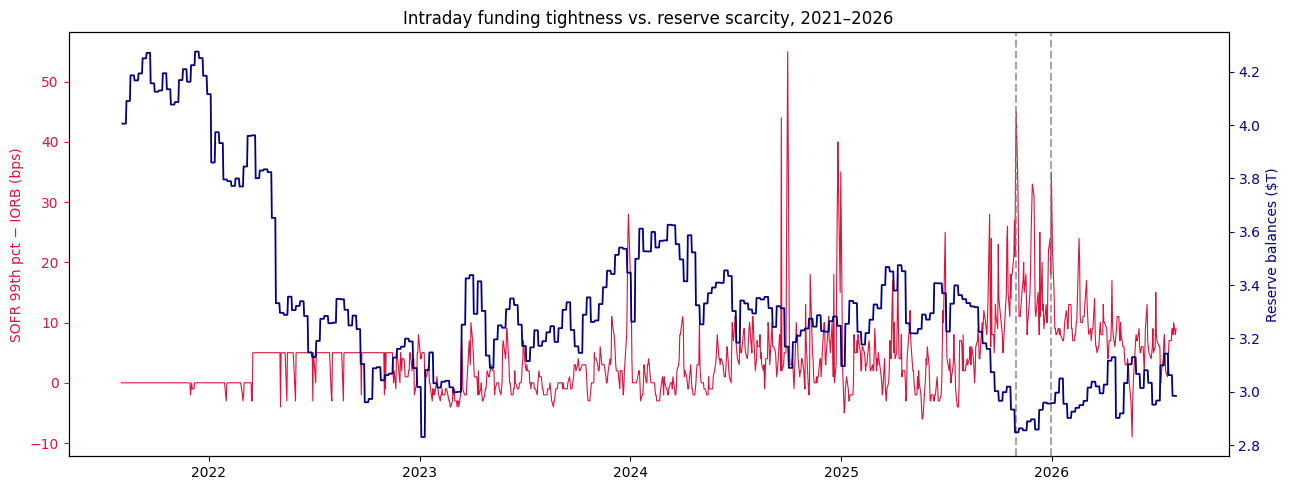

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
import matplotlib.pyplot as plt

# FIX 1: WRESBAL is in MILLIONS, not billions (2,848,021 = $2.85T)
master["WRESBAL_bn"] = master["WRESBAL"] / 1000

# FIX 2: 1830 rows are calendar days; SOFR is business-day only.
# Rolling stats must run on business days or the 252-window spans ~14 months.
master["is_business_day"] = master["SOFR"].notna()

d = master[master["is_business_day"]].dropna(subset=["sofr99_iorb_bps"]).copy()
roll = d["sofr99_iorb_bps"].rolling(252, min_periods=60)
d["tightness_z"] = (d["sofr99_iorb_bps"] - roll.mean()) / roll.std()

# FIX 3: report in billions, not raw millions
keep = [c for c in ["date","sofr99_iorb_bps","tightness_z","WRESBAL_bn",
                    "RPONTSYD","is_quarter_end"] if c in d.columns]
stress = d.nlargest(25, "sofr99_iorb_bps")[keep]
print(stress.head(12).to_string(index=False))

# Sanity checks — print, don't halt
oct31 = master.loc[master["date"]=="2025-10-31","RPONTSYD"]
print(f"\n[{'PASS' if len(oct31) and abs(oct31.iloc[0]-29.4)<0.01 else 'WARN'}] Oct 31 2025 repo == 29.4")
print(f"[{'PASS' if 2500 < master['WRESBAL_bn'].max() < 4500 else 'WARN'}] WRESBAL in $2.5–4.5T range")
print(f"business days: {master['is_business_day'].sum()} of {len(master)} rows")

fig, ax1 = plt.subplots(figsize=(13,5))
ax1.plot(d["date"], d["sofr99_iorb_bps"], lw=.8, color="crimson")
ax1.set_ylabel("SOFR 99th pct − IORB (bps)", color="crimson")
ax1.tick_params(axis="y", colors="crimson")
ax2 = ax1.twinx()
ax2.plot(master["date"], master["WRESBAL_bn"]/1000, lw=1.3, color="navy")   # -> $T
ax2.set_ylabel("Reserve balances ($T)", color="navy")
ax2.tick_params(axis="y", colors="navy")
for dt in ("2025-10-31", "2025-12-31"):
    ax1.axvline(pd.Timestamp(dt), ls="--", color="gray", alpha=.7)
ax1.set_title("Intraday funding tightness vs. reserve scarcity, 2021–2026")
plt.tight_layout(); plt.savefig("fig1_tightness.png", dpi=300, bbox_inches="tight"); plt.show()

master.to_csv("master_dataset.csv", index=False)
stress.to_csv("stress_days.csv", index=False)
if fdic is not None: fdic.to_csv("fdic_institutions.csv", index=False)

from google.colab import files
for fn in ("master_dataset.csv","stress_days.csv","fig1_tightness.png"):
    files.download(fn)